In [1]:
%reload_ext autoreload
%autoreload 2
import sys
sys.path.append('../') 
from visualisation import *
import duckdb


In [2]:
os.getcwd()

'/home/hossein/CICCADA/SolA2024'

In [72]:
site_meta_data = glob('./project_ciccada/**/**/site_*.csv')
circuit_meta_data = glob('./project_ciccada/**/**/circuit_*.csv')
print(f"Number of site metadata files: {len(site_meta_data)}")  
print(f"Number of circuit metadata files: {len(circuit_meta_data)}")
site_meta_data = site_meta_data[0]
circuit_meta_data = circuit_meta_data[0]
site_meta_data = pd.read_csv(site_meta_data)
circuit_meta_data = pd.read_csv(circuit_meta_data)
num_unique_sites = site_meta_data['site_id'].unique().shape[0]
print(f"Number of unique sites: {num_unique_sites}")

Number of site metadata files: 1
Number of circuit metadata files: 1
Number of unique sites: 39474


In [4]:
circuit_meta_data['circuit_type'].value_counts()

circuit_type
pv_site_net                 73882
ac_load_net                 64074
load_air_conditioner         4678
load_other                   4186
load_powerpoint              2263
load_hot_water               1874
load_stove                   1141
load_lighting                1095
load_subboard                1089
ac_load                       850
load_pool                     787
battery_storage               776
load_shed                     562
pv_site                       397
load_tenant                   372
load_kitchen                  270
load_hot_water_solar          263
load_ev_charger               258
load_spa                      234
load_studio                   233
load_common_area              212
load_machine                  187
load_refrigerator             171
load_garage                   158
load_office                   149
load_laundry                  137
load_air_compressor            50
load_generator                 49
load_washer                    32
l

In [5]:
def get_both_pv_site_nd_net(group):
    circuit_types = group['circuit_type'].unique()
    if 'pv_site_net' in circuit_types and 'pv_site' in circuit_types:
        return True
    else:
        return None
def get_only_pv_site(group):
    circuit_types = group['circuit_type'].unique()
    if 'pv_site' in circuit_types and 'pv_site_net' not in circuit_types:
        return True
    else:
        return None
def get_only_pv_site_net(group):
    circuit_types = group['circuit_type'].unique()
    if 'pv_site_net' in circuit_types and 'pv_site' not in circuit_types:
        return True
    else:
        return None
a_both = circuit_meta_data.groupby('site_id').apply(get_both_pv_site_nd_net)
a_pv_site_only = circuit_meta_data.groupby('site_id').apply(get_only_pv_site)
a_pv_site_net_only = circuit_meta_data.groupby('site_id').apply(get_only_pv_site_net)
a_both = a_both.dropna().reset_index()
a_pv_site_only = a_pv_site_only.dropna().reset_index()
a_pv_site_net_only = a_pv_site_net_only.dropna().reset_index()
selected_sites_both = a_both['site_id'].to_list()
selected_sites_pv_site_only = a_pv_site_only['site_id'].to_list()
selected_sites_pv_site_net_only = a_pv_site_net_only['site_id'].to_list()
print(f"Number of sites with both pv_site_net and pv_site: {len(selected_sites_both)}")
print(f"Number of sites with only pv_site: {len(selected_sites_pv_site_only)}")
print(f"Number of sites with only pv_site_net: {len(selected_sites_pv_site_net_only)}")

Number of sites with both pv_site_net and pv_site: 7
Number of sites with only pv_site: 212
Number of sites with only pv_site_net: 37776


In [121]:
37776/39474

0.956984344125247

In [75]:
ts_files = glob('./project_ciccada/**/**/**/**/**/1/*.parquet')

In [76]:
df = pd.concat(pd.read_parquet(ts_file) for ts_file in ts_files)

In [8]:
count_isna = df.isna().sum().sum()
print(f"Number of  NaN values: {count_isna}")

Number of  NaN values: 6077533


In [135]:
21825/39474

0.5528955768353854

In [9]:
a = circuit_meta_data.groupby(['site_id', 'device_id']).agg({'circuit_type': lambda x: sum(x=='pv_site_net')})
a['circuit_type'].value_counts()

circuit_type
1    22790
3    13440
0     6524
2     2623
6      714
4      277
5       17
7        7
Name: count, dtype: int64

In [143]:
34261/39474

0.8679383898262147

In [10]:
a = circuit_meta_data.groupby(['site_id']).agg({'device_id': lambda x: len(x.unique())})
a['device_id'].value_counts()

device_id
1     34261
2      4415
3       510
4       154
5        54
6        33
7        19
8        10
9         8
10        7
11        6
12        5
14        3
13        3
15        3
22        1
17        1
16        1
25        1
Name: count, dtype: int64

In [11]:
circuit_meta_data_both0 = circuit_meta_data[circuit_meta_data['site_id'].isin(selected_sites_both[1:2])]

In [ ]:
df0['device_id'].unique()

array([130979])

In [136]:
df

,device_id,circuit_id,t_stamp,power,energy,energy_reactive,energy_import,energy_export,energy_reactive_import,energy_reactive_export,power_factor,voltage,current
0,131458,599175,2024-01-02 23:40:00,-5971.5000,-497.6250,22.2710,NaN,NaN,NaN,NaN,0.998001,239.67,24.9600
1,131458,599174,2024-01-02 23:40:00,-2611.4300,-217.6190,49.8240,NaN,NaN,NaN,NaN,0.950192,239.67,11.1800
2,131458,599175,2024-01-02 23:20:00,-5007.9600,-417.3300,20.0890,NaN,NaN,NaN,NaN,0.997688,239.26,21.0000
3,131458,599174,2024-01-02 23:20:00,-1659.9300,-138.3280,46.9660,NaN,NaN,NaN,NaN,0.896637,239.26,8.9300
4,131458,599175,2024-01-02 23:05:00,-4431.5100,-369.2930,17.3330,NaN,NaN,NaN,NaN,0.997802,237.80,18.6000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22567379,125915,231007,2024-01-01 20:05:00,-2.3600,-0.1967,-7.7564,0.0000,0.1967,0.0000,7.7564,0.000643,239.05,0.4935
22567380,107242,336266,2024-01-01 20:25:00,1497.3500,124.7792,1.4619,124.7792,0.0000,1.4619,0.0000,0.999863,237.45,6.3895
22567381,107242,336269,2024-01-01 20:25:00,732.0967,61.0081,-78.3117,61.0081,0.0000,0.0000,78.3117,0.377686,237.45,5.4190
22567382,107242,336266,2024-01-01 20:45:00,2066.8167,172.2347,1.3958,172.2347,0.0000,1.3958,0.0000,0.999934,236.75,7.9820


In [12]:
circuit_meta_data_both0

,site_id,device_id,circuit_id,circuit_polarity,circuit_type
63726,789801534,192562,240432,1,pv_site_net
63727,789801534,192562,240433,1,pv_site_net
63728,789801534,192562,240434,1,pv_site_net
63729,789801534,192562,240435,1,pv_site_net
63730,789801534,192562,240436,1,pv_site_net
63731,789801534,192562,240437,1,pv_site
63852,789801534,177212,242558,1,ac_load_net
63853,789801534,177212,242559,1,ac_load_net
63854,789801534,177212,242560,1,ac_load_net


In [13]:
site_meta_data.query(f'site_id in {selected_sites_both}')

,site_id,state,postcode,dnsp_name,dc_capacity_kw,ac_capacity_kw,export_limit_kw
4285,1430574402,SA,5017,SAPN,29.64,30.0,NaN
8669,2010213275,NSW,2580,Essential,0.99,1.0,NaN
13184,1707521716,QLD,4807,Ergon,29.70,27.6,NaN
15987,789801534,QLD,4205,Energex,449.92,400.0,NaN
19197,892037246,QLD,4818,Ergon,13.20,10.0,5.0
25525,131854079,NSW,2350,Essential,18.87,15.0,NaN
31731,2108152192,NSW,2101,Ausgrid,4.25,4.6,NaN


In [14]:
df_both = df[df['device_id'].isin(circuit_meta_data_both0['device_id'].unique())]
df_both['t_stamp'] = pd.to_datetime(df_both['t_stamp'], unit='s')
df_both = df_both.merge(circuit_meta_data_both0[['circuit_id', 'site_id','circuit_polarity', 'circuit_type']], on='circuit_id', how='left')
df_both = df_both.query('t_stamp =="2024-01-01 12:00:00"').reset_index(drop=True)
df_both[['site_id','device_id','circuit_id', 'power', 'energy',
       'energy_reactive', 'energy_import', 'energy_export',
       'energy_reactive_import', 'energy_reactive_export', 'power_factor', 'circuit_polarity', 'circuit_type'
       ]]

,site_id,device_id,circuit_id,power,energy,energy_reactive,energy_import,energy_export,energy_reactive_import,energy_reactive_export,power_factor,circuit_polarity,circuit_type
0,789801534,177212,242558,14090.1833,1174.1819,-233.0089,1174.1819,0.0000,0.0000,233.0089,0.962112,1,ac_load_net
1,789801534,177212,242559,10534.6233,877.8853,857.6778,877.8853,0.0000,857.6778,0.0000,0.511642,1,ac_load_net
2,789801534,177212,242560,7792.1000,649.3417,-1.3742,649.3417,0.0000,2.5381,3.9122,0.999996,1,ac_load_net
3,789801534,192562,240432,-2.5400,-0.2117,13.9897,0.0000,0.2117,13.9897,0.0000,0.000229,1,pv_site_net
4,789801534,192562,240433,33.8300,2.8192,10.0686,2.8192,0.0000,10.0686,0.0000,0.072700,1,pv_site_net
5,789801534,192562,240434,2.8300,0.2358,12.6511,0.2358,0.0000,12.6511,0.0000,0.000347,1,pv_site_net
6,789801534,192562,240435,-6.4167,-0.5347,9.3064,0.0000,0.5347,9.3064,0.0000,0.003290,1,pv_site_net
7,789801534,192562,240436,-48.8600,-4.0717,13.8133,0.0000,4.0717,13.8133,0.0000,0.079941,1,pv_site_net
8,789801534,192562,240437,-13.6867,-1.1406,11.0639,0.0000,1.1406,11.0639,0.0000,0.010516,1,pv_site


In [117]:
df_both.groupby('device_id').agg({'power': ['mean', 'max', 'min', 'sum']})

power                                 
                   mean         max      min         sum
device_id                                               
177212     10805.635533  14090.1833  7792.10  32416.9066
192562        -5.807233     33.8300   -48.86    -34.8434

In [15]:
circuit_meta_data_net_only = circuit_meta_data[circuit_meta_data['site_id'].isin(selected_sites_pv_site_net_only)]
df_net_only = df[df['device_id'].isin(circuit_meta_data_net_only['device_id'].unique())]
df_net_only['t_stamp'] = pd.to_datetime(df_net_only['t_stamp'], unit='s', utc=True)
df_net_only['t_stamp'] = df_net_only['t_stamp'].dt.tz_convert(pytz.FixedOffset(10*60))  # Convert to Sydney local time (UTC+10:30)
df_net_only = df_net_only.merge(circuit_meta_data_net_only[['circuit_id', 'circuit_polarity', 'circuit_type']], on='circuit_id', how='left')
df_net_only['power_corrected'] = df_net_only['power']*df_net_only['circuit_polarity']/1000 
# df_ac_net = df_net_only.query("circuit_type=='ac_load_net'").reset_index(drop=True)
# df_pv_gross = df_net_only.query("circuit_type=='pv_site'").reset_index(drop=True)
# df_net_only = df_net_only.query("circuit_type=='pv_site_net'").reset_index(drop=True)
# df_ac_net['power_corrected'] = df_ac_net['power']*df_ac_net['circuit_polarity']/1000 
# df_pv_gross['power_corrected'] = df_pv_gross['power']*df_pv_gross['circuit_polarity']/1000 

In [22]:
selected_devices = df_net_only.query(f"power_corrected < -1")['device_id'].unique()
# df0 = df_net_only[df_net_only['device_id'].isin(selected_devices[:1])]
# selected_devices = df_net_only.query(f"power_corrected < -1")['device_id'].unique()
# df0 = df_ac_net[df_ac_net['device_id'].isin(selected_devices[:1])]

In [ ]:
df.merge(site_meta_data[['site_id', 'site_name']], on='site_id', how='left').merge(

(21940,)

In [23]:
df_net_only['device_id'].unique().shape

(21208,)

In [24]:
len(selected_devices)

15931

In [92]:
df_net_only['t_stamp'].max(), df_net_only['t_stamp'].min()

(Timestamp('2024-01-03 09:55:00+1000', tz='pytz.FixedOffset(600)'),
 Timestamp('2024-01-01 10:00:00+1000', tz='pytz.FixedOffset(600)'))

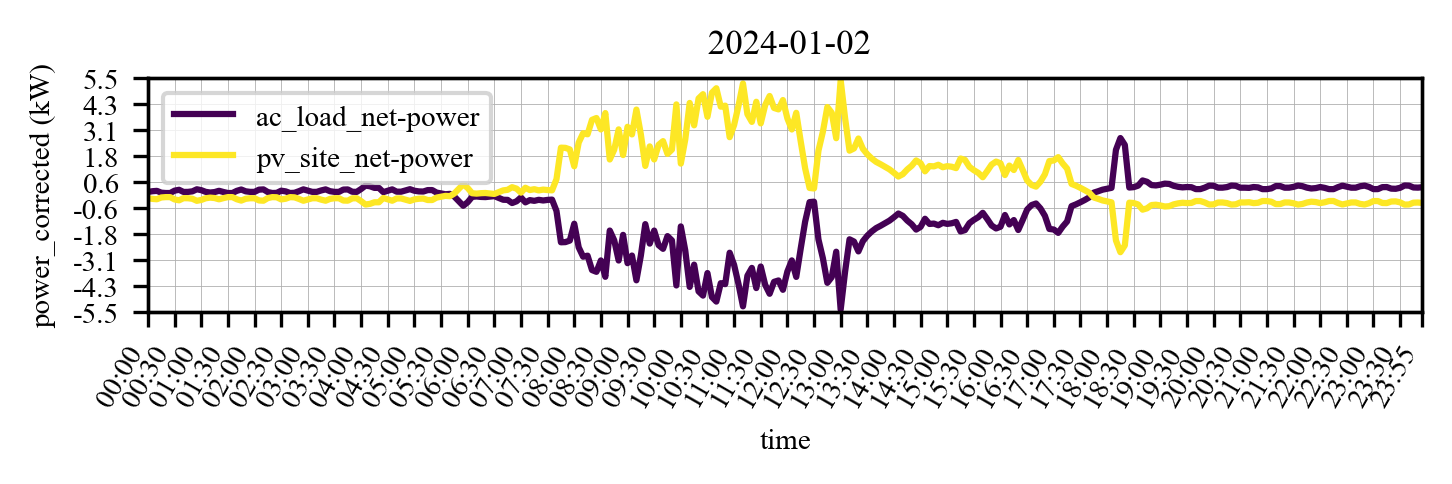

In [129]:
start_time = '2024-01-02 00:00:00+10:00' # In sydney local time
end_time = '2024-01-03 00:00:00+10:00' # In sydney local time

num_ticks = 24*2+1
# save_as = 'Figures/EDP_voltwatt_12Nov.jpeg'
save_as = ''
x_label = 'time'
y_labels = ['power_corrected (kW)']

plt_config = {'power_corrected': [0, 0, '-', None, None]
}

color_nights=False
# color_by = 'group'
color_by = 'attribute'
ax_digit = '1.1f'
a=my_plot4(start_time, end_time, df0, plt_config=plt_config, ax_digit= ax_digit,
          group_attr='circuit_type', time_attr='t_stamp', color_nights=color_nights,cmap='viridis',
          figsize=[12/2.54,1.5],  same_scale=1, fontsize=7, fontname='Times New Roman', plot_total=False, plot_total_func=['sum', [lambda x: max(x), 'max']], 
          num_ticks=num_ticks, num_yticks=10, dpi=300,  x_format= '%H:%M', 
           legend_loc=['upper left'], 
           x_label=x_label, y_labels=y_labels, color_by=color_by,
plot_period=np.timedelta64(1, 'D'), save_as=save_as, rotation = 60, step=0, gridwidth=[0.2, .2], legend_join='-', title='', legend_i=0, legend_j=-10, title_i=0, only1title=0)
a.do()

In [2]:
import polars as pl
from pathlib import Path

In [3]:
site_meta_data = list(Path("project_ciccada").rglob("site_*.csv"))
circuit_meta_data = list(Path("project_ciccada").rglob("circuit_*.csv"))
ts_files = list(Path("project_ciccada").rglob("*.parquet"))

In [4]:
site_meta_data = pl.read_csv(site_meta_data[0])
circuit_meta_data = pl.read_csv(circuit_meta_data[0])

In [ ]:
frames = [pl.read_parquet(ts_file).lazy() for ts_file in ts_files]

In [5]:
lf = pl.read_parquet(ts_files[0]).lazy()

In [6]:
lf2 = pl.read_parquet(ts_files[1]).lazy()

In [11]:
str(ts_files[0])

'project_ciccada/historical_data/data_dump_20240101_20240201/metrology/2024/1/27/20240127.parquet'

In [13]:
aa = pd.read_parquet(ts_files[0])

In [14]:
ba = pd.read_parquet(ts_files[1])

In [4]:
os.getcwd()

'/home/hossein/CICCADA/SolA2024'

In [36]:
join_the_three = f""" from
 '{os.getcwd()}/project_ciccada/**/*.parquet'  as ts
    left join '{os.getcwd()}/project_ciccada/**/circuit_*.csv' as c 
    on ts.device_id = c.device_id and ts.circuit_id = c.circuit_id 
    join '{os.getcwd()}/project_ciccada/**/site_*.csv' as s
    on c.site_id = s.site_id
"""

In [37]:

query = f"""
    select * 
    {join_the_three}
    limit 1
    \
"""
db = duckdb.query(query).to_df()
db

,device_id,circuit_id,t_stamp,power,energy,energy_reactive,energy_import,energy_export,energy_reactive_import,energy_reactive_export,...,circuit_id_1,circuit_polarity,circuit_type,site_id_1,state,postcode,dnsp_name,dc_capacity_kw,ac_capacity_kw,export_limit_kw
0,124514,526440,2024-01-01,512.44,42.7033,-55.7481,42.7033,0.0,0.0,55.7481,...,526440,1,ac_load_net,226934824,QLD,4850,Ergon,13.12,10.0,NaN


In [38]:

query = f"""
    SELECT count(distinct s.site_id) as num_sites, s.state 
    {join_the_three}
    group by state
    \
"""
db = duckdb.query(query).to_df()
db

,num_sites,state
0,7963,NSW
1,263,ACT
2,873,WA
3,7000,QLD
4,284,TAS
5,225,NT
6,1702,SA
7,1868,VIC


In [81]:

query = f"""
    With pv_power as (SELECT s.site_id, ts.device_id, ts.circuit_id, ts.t_stamp, power*circuit_polarity/1000 as corrected_power_kw 
    {join_the_three}
    where (circuit_type='pv_site_net' or circuit_type='pv_site') and t_stamp >= '2024-01-01 00:00:00' and t_stamp < '2024-02-02 00:00:00'
    )
    select site_id, device_id, circuit_id, count(t_stamp) as t_stamp_count
    from pv_power
    group by site_id, device_id, circuit_id
    
"""
db = duckdb.query(query).to_df()
db

,site_id,device_id,circuit_id,t_stamp_count
0,1225907536,107925,548956,8887
1,1534684624,120795,214491,8924
2,118022502,104227,406585,8924
3,184402566,181664,563606,8925
4,361625485,125504,446513,8937
...,...,...,...,...
38617,484104841,98992,463885,772
38618,411476405,134485,417516,141
38619,399689415,192685,480319,261
38620,1446807269,107256,592370,192


In [99]:
8928-288

8640

In [93]:
8928/288

31.0

In [102]:
db.query('t_stamp_count < 8640')

,site_id,t_stamp_count
4,137207543,7498
8,1457547481,8389
39,984657795,7738
40,945131622,7770
46,222122353,7580
...,...,...
19347,1485752652,267
19348,510716320,301
19349,1339252917,292
19350,2038932393,45


In [98]:
db['t_stamp_count'].value_counts()

t_stamp_count
8928    2000
8927    1465
8926    1259
8925    1029
8924     778
        ... 
626        1
8384       1
3068       1
2244       1
2222       1
Name: count, Length: 2686, dtype: int64

In [86]:

query = f"""
    With site_pv_power as (SELECT s.site_id,  ts.t_stamp, sum(power*circuit_polarity)/1000 as corrected_power_kw 
    {join_the_three}
    where (circuit_type='pv_site_net' or circuit_type='pv_site') 
    group by s.site_id, ts.t_stamp
    )
    select site_id, count(t_stamp) as t_stamp_count
    from site_pv_power
    group by site_id 
    
"""
db = duckdb.query(query).to_df()
db

,site_id,t_stamp_count
0,1046265825,8822
1,1476436565,8819
2,1326518094,8738
3,1008392762,8893
4,137207543,7498
...,...,...
19347,1485752652,267
19348,510716320,301
19349,1339252917,292
19350,2038932393,45


In [87]:
db['t_stamp_count'].value_counts()

t_stamp_count
8928    2000
8927    1465
8926    1259
8925    1029
8924     778
        ... 
626        1
8384       1
3068       1
2244       1
2222       1
Name: count, Length: 2686, dtype: int64

In [129]:

query = f"""
    With pv_power as (SELECT s.site_id, ts.device_id, ts.circuit_id, ts.t_stamp, power*circuit_polarity/1000 as corrected_power_kw 
    {join_the_three}
    where circuit_type='pv_site_net' or circuit_type='pv_site'
    ),
    negative_inverters as (
    select   site_id, device_id, circuit_id
    from pv_power
    where t_stamp >= '2024-01-02 00:00:00' and t_stamp < '2024-01-03 00:00:00'
    group by site_id, device_id, circuit_id
    having min(corrected_power_kw) < -.1
    order by count(corrected_power_kw) desc
    )
    select site_id, device_id, circuit_id, count(t_stamp) as t_stamp_count
    from pv_power
    where circuit_id in (select circuit_id from negative_inverters) and t_stamp >= '2024-01-02 00:00:00' and t_stamp < '2024-01-03 00:00:00'
    group by site_id, device_id, circuit_id
    order by t_stamp_count desc
    
"""
db = duckdb.query(query).to_df()
db

,site_id,device_id,circuit_id,t_stamp_count
0,976381061,127583,227128,679
1,383976255,99714,587592,576
2,2038008181,119614,209762,492
3,1382130678,102812,526927,479
4,425704325,89006,547779,476
...,...,...,...,...
1578,1834563946,105472,454024,184
1579,1040399007,122049,591259,122
1580,1040399007,122185,591265,122
1581,93730315,118229,512289,68


In [130]:

query = f"""
    With pv_power as (SELECT s.site_id, ts.device_id, ts.circuit_id, ts.t_stamp, power*circuit_polarity/1000 as corrected_power_kw 
    {join_the_three}
    where circuit_type='pv_site_net' or circuit_type='pv_site'
    ),
    negative_inverters as (
    select   site_id, device_id, circuit_id
    from pv_power
    group by site_id, device_id, circuit_id
    having min(corrected_power_kw) < -.1
    order by count(corrected_power_kw) desc
    limit 1
    )
    select site_id, device_id, circuit_id, t_stamp, corrected_power_kw
    from pv_power
    where circuit_id in (select circuit_id from negative_inverters)
    order by t_stamp
    
"""
db = duckdb.query(query).to_df()
db

,site_id,device_id,circuit_id,t_stamp,corrected_power_kw
0,337091559,107278,500570,2024-01-07 01:15:00,18.897523
1,337091559,107278,500570,2024-01-07 01:20:00,48.611180
2,337091559,107278,500570,2024-01-07 01:25:00,38.655930
3,337091559,107278,500570,2024-01-07 01:30:00,25.697147
4,337091559,107278,500570,2024-01-07 01:35:00,13.070207
...,...,...,...,...,...
13962,337091559,107278,500570,2024-01-31 23:45:00,55.543437
13963,337091559,107278,500570,2024-01-31 23:50:00,55.834353
13964,337091559,107278,500570,2024-01-31 23:55:00,57.070727
13965,337091559,107278,500570,2024-01-31 23:55:00,57.070727


In [131]:
db['t_stamp'] = pd.to_datetime(db['t_stamp'], unit='s', utc=True)
db['t_stamp'] = db['t_stamp'].dt.tz_convert(pytz.FixedOffset(10*60))


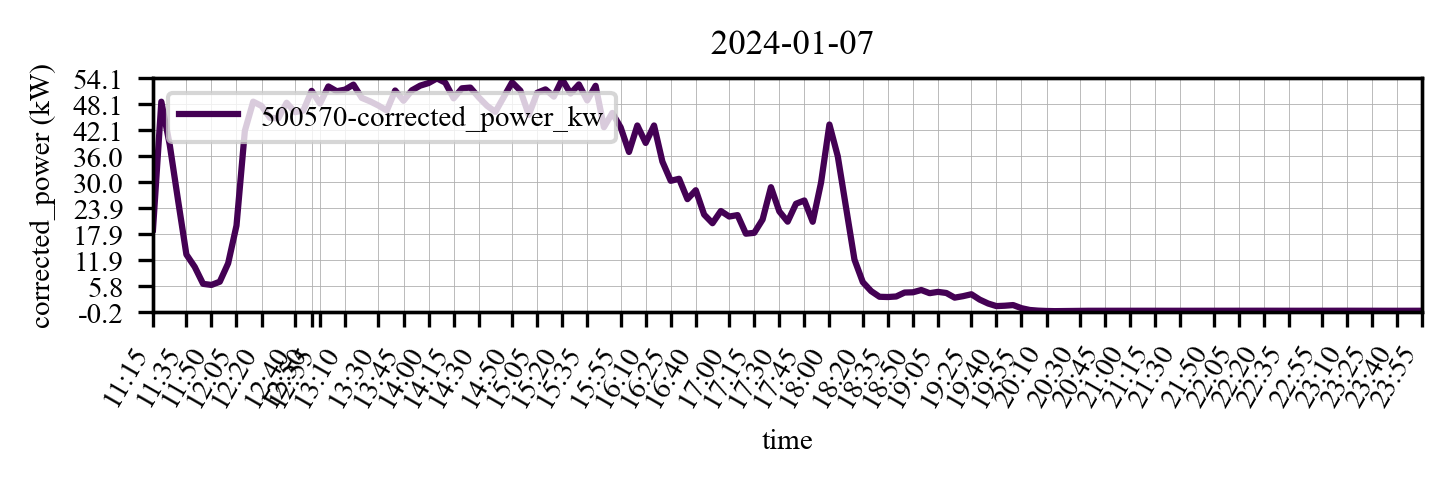

In [136]:
start_time = '2024-01-07 00:00:00+10:00' # In sydney local time
end_time = '2024-01-08 00:00:00+10:00' # In sydney local time

num_ticks = 24*2+1
# save_as = 'Figures/EDP_voltwatt_12Nov.jpeg'
save_as = ''
x_label = 'time'
y_labels = ['corrected_power (kW)']

plt_config = {'corrected_power_kw': [0, 0, '-', None, None]
}

color_nights=False
# color_by = 'group'
color_by = 'attribute'
ax_digit = '1.1f'
a=my_plot4(start_time, end_time, db, plt_config=plt_config, ax_digit= ax_digit,
          group_attr='circuit_id', time_attr='t_stamp', color_nights=color_nights,cmap='viridis',
          figsize=[12/2.54,1.5],  same_scale=1, fontsize=7, fontname='Times New Roman', plot_total=False, plot_total_func=['sum', [lambda x: max(x), 'max']], 
          num_ticks=num_ticks, num_yticks=10, dpi=300,  x_format= '%H:%M', 
           legend_loc=['upper left'], 
           x_label=x_label, y_labels=y_labels, color_by=color_by,
plot_period=np.timedelta64(1, 'D'), save_as=save_as, rotation = 60, step=0, gridwidth=[0.2, .2], legend_join='-', title='', legend_i=0, legend_j=None, title_i=0, only1title=0)
a.do()